<center>

## Fitting and Alignment

</center>

In [2]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import random
import os

In [3]:
# Create output folder
os.makedirs('results', exist_ok=True)

---
### Question 1 – Line Fitting with Total Least Squares and RANSAC

#### 1(a) – Total Least Squares on Line 1

TLS Line 1 parameters:
  a = 0.773562
  b = -0.633721
  c = -3.794192
  Equation: 0.7736·x + -0.6337·y + -3.7942 = 0
  Slope-intercept form: y = 1.2207·x + -5.9872


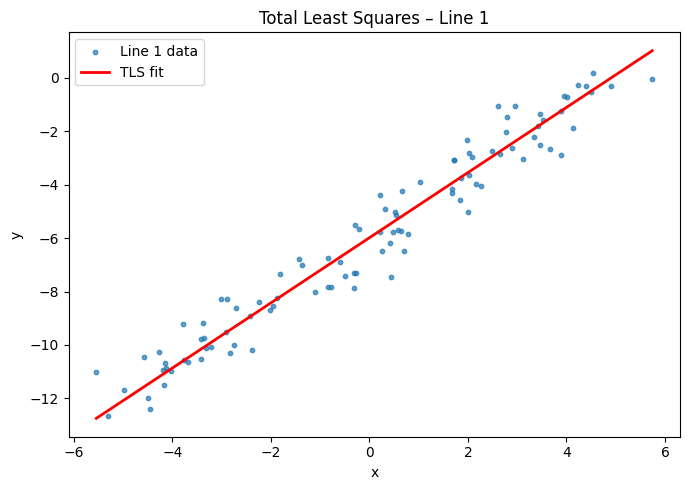

In [4]:
# Load dataset
D = np.genfromtxt('lines.csv', delimiter=',', skip_header=1)

# Extract columns for line 1 (x1, y1)
x1 = D[:, 0]
y1 = D[:, 3]

def total_least_squares(x, y):
    """
    Fit a line using Total Least Squares (TLS).
    Returns (a, b, c) such that ax + by + c = 0, normalized so that a^2 + b^2 = 1.
    """
    n = len(x)
    # Center the data
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_c = x - x_mean
    y_c = y - y_mean

    # Build data matrix
    A = np.column_stack([x_c, y_c])

    # SVD – the normal to the line is the last right singular vector
    U, S, Vt = np.linalg.svd(A)
    a, b = Vt[-1]          # normal vector (a, b)

    # c from passing through centroid: a*x_mean + b*y_mean + c = 0
    c = -(a * x_mean + b * y_mean)
    return a, b, c

a, b, c = total_least_squares(x1, y1)
print(f"TLS Line 1 parameters:")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")
print(f"  c = {c:.6f}")
print(f"  Equation: {a:.4f}·x + {b:.4f}·y + {c:.4f} = 0")

# Slope-intercept form (if b != 0): y = -(a/b)x - (c/b)
slope = -a / b
intercept = -c / b
print(f"  Slope-intercept form: y = {slope:.4f}·x + {intercept:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x1, y1, s=10, label='Line 1 data', alpha=0.7)
x_plot = np.linspace(x1.min(), x1.max(), 200)
y_plot = slope * x_plot + intercept
ax.plot(x_plot, y_plot, 'r-', lw=2, label='TLS fit')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Total Least Squares – Line 1')
ax.legend(); plt.tight_layout()
plt.savefig('results/Q1_tls_line1.png', dpi=120)
plt.show()